PARAMS: {'clf__ccp_alpha': 0.0, 'clf__criterion': 'entropy', 'clf__max_depth': 3, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'pca__n_components': 3}

ACCURACY:
Score: 0.8016 ± 0.0606

PRECISION:
Score: 0.7282 ± 0.0630

RECALL:
Score: 0.9358 ± 0.0396

BALANCED_ACCURACY:
Score: 0.8081 ± 0.0598

F1:
Score: 0.8179 ± 0.0482

ROC_AUC:
Score: 0.8556 ± 0.0565

SPECIFICITY:
Score: 0.6087 ± 0.0000


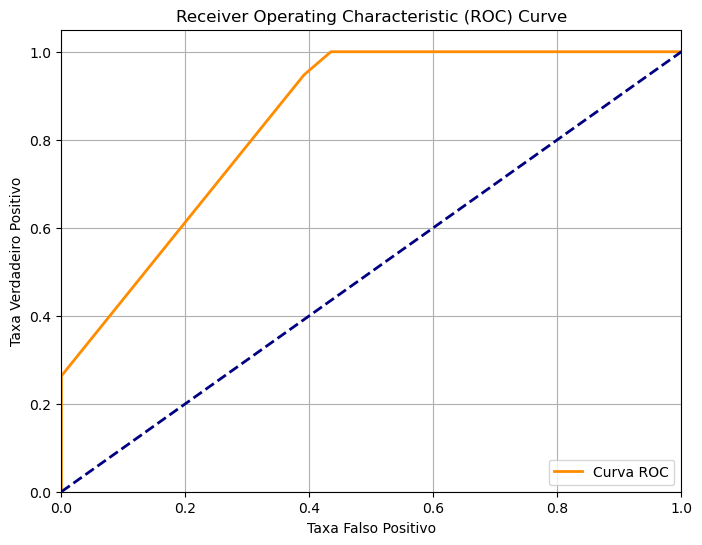

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, confusion_matrix
import matplotlib.pyplot as plt

# Carregando Dataset
df_sonar = pd.read_csv('sonar_dataset.csv', sep=',',header=None)
df_sonar
X_treino, X_teste, y_treino, y_teste = train_test_split(df_sonar.iloc[:, 0:59], df_sonar[60].apply(lambda x: 1 if x == 'R' else 0), test_size=0.2)

# Pipeline - Pré-processamento
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('clf', DecisionTreeClassifier(random_state=7))
])

# Parametros para o Classificador
kfolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

parametros = {
    'pca__n_components': [3, 5, 7, 10, 20],
    'clf__max_depth': [3, 5, 7, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__criterion': ['gini', 'entropy'],
    'clf__ccp_alpha': [0.0, 0.001, 0.01, 0.1]  # Pruning (poda na arvore de decisão)
}

scores = [
    'accuracy',
    'precision',
    'recall',
    'balanced_accuracy', # Média entre Especififdade e sensitividade
    'f1',
    'roc_auc'
]
grid_search = GridSearchCV(
    pipeline,
    param_grid=parametros,
    scoring=scores,
    cv=kfolds,
    refit='f1',
    return_train_score=True
)
grid_search.fit(X_treino,y_treino)

best_results = {}
best_idx = grid_search.cv_results_['rank_test_f1'].argmin() 
best_results['params'] = grid_search.cv_results_['params'][best_idx]
for metrica in scores:
    
    best_results[metrica] = {
        'score': grid_search.cv_results_[f'mean_test_{metrica}'][best_idx],
        'std': grid_search.cv_results_[f'std_test_{metrica}'][best_idx]
    }

# sensibilidade e especificidade (correção)

y_proba = grid_search.predict_proba(X_teste)[:, 1]
fpr, tpr, thresholds = roc_curve(y_teste, y_proba)

y_pred = grid_search.predict(X_teste)
cm = confusion_matrix(y_teste, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)

best_results['specificity'] = {
    'score': specificity,
    'std': 0
}
    
    
print(f"PARAMS: {best_results['params']}")
for metric, data in best_results.items():
    if(metric != 'params'):
        print(f"\n{metric.upper()}:")
        print(f"Score: {data['score']:.4f} ± {data['std']:.4f}")

# Plotagem curva roc (Correção)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa Falso Positivo')
plt.ylabel('Taxa Verdadeiro Positivo')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Interpretação dos Dados:
# Os dados demonstram que apesar de apresentarem uma boa correlação entre valores das features e a classificação,
# todos os índices aproximam-se de 80%, seria necessário mais amostras ou uma feature mais determinante para construir um modelo cuja classificação seja robusta para o discernimento do sonar.
# Dependendo do caso de uso dessa detecção é possível estimar uma faixa na qual a acurácia do modelo tenha um requisito mínimo de acertos,
# por exemplo, se o trabalho do sonar for crítico e cirúrgico talvez 80% , 4 corretas em 5 detecções, não seja suficiente para atender a expectativa da classificação.
